In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, butter, filtfilt, iirnotch
import pandas as pd



In [5]:
# ----------------------------
# Parámetros generales
# ----------------------------
fs = 500            # Frecuencia de muestreo [Hz]
T = 10              # Duración [s]
N = fs * T
t = np.arange(N) / fs

In [6]:
# ===============================
# Cargar ECG
# ===============================
url = "https://raw.githubusercontent.com/rfurch/unlpam_noise/refs/heads/main/data/ecg_sample_01.csv"
df = pd.read_csv(url)

print(df.head())

#df = pd.read_csv("sample.csv")
ecg = df.iloc[:, 0].values
N = len(ecg)
t = np.arange(N) / fs

   Sample Value
0     -0.001622
1      0.002459
2      0.000177
3     -0.015121
4     -0.038852


In [9]:
# ----------------------------
# 1) Ruido blanco
# ----------------------------
np.random.seed(0)
ruido_blanco = np.random.normal(0, 1, N)


# ----------------------------
# 3) PSD usando Welch
# ----------------------------
f_rw, psd_rw = welch(ruido_blanco, fs, nperseg=300)
f_ecg, psd_ecg = welch(ecg, fs, nperseg=300)


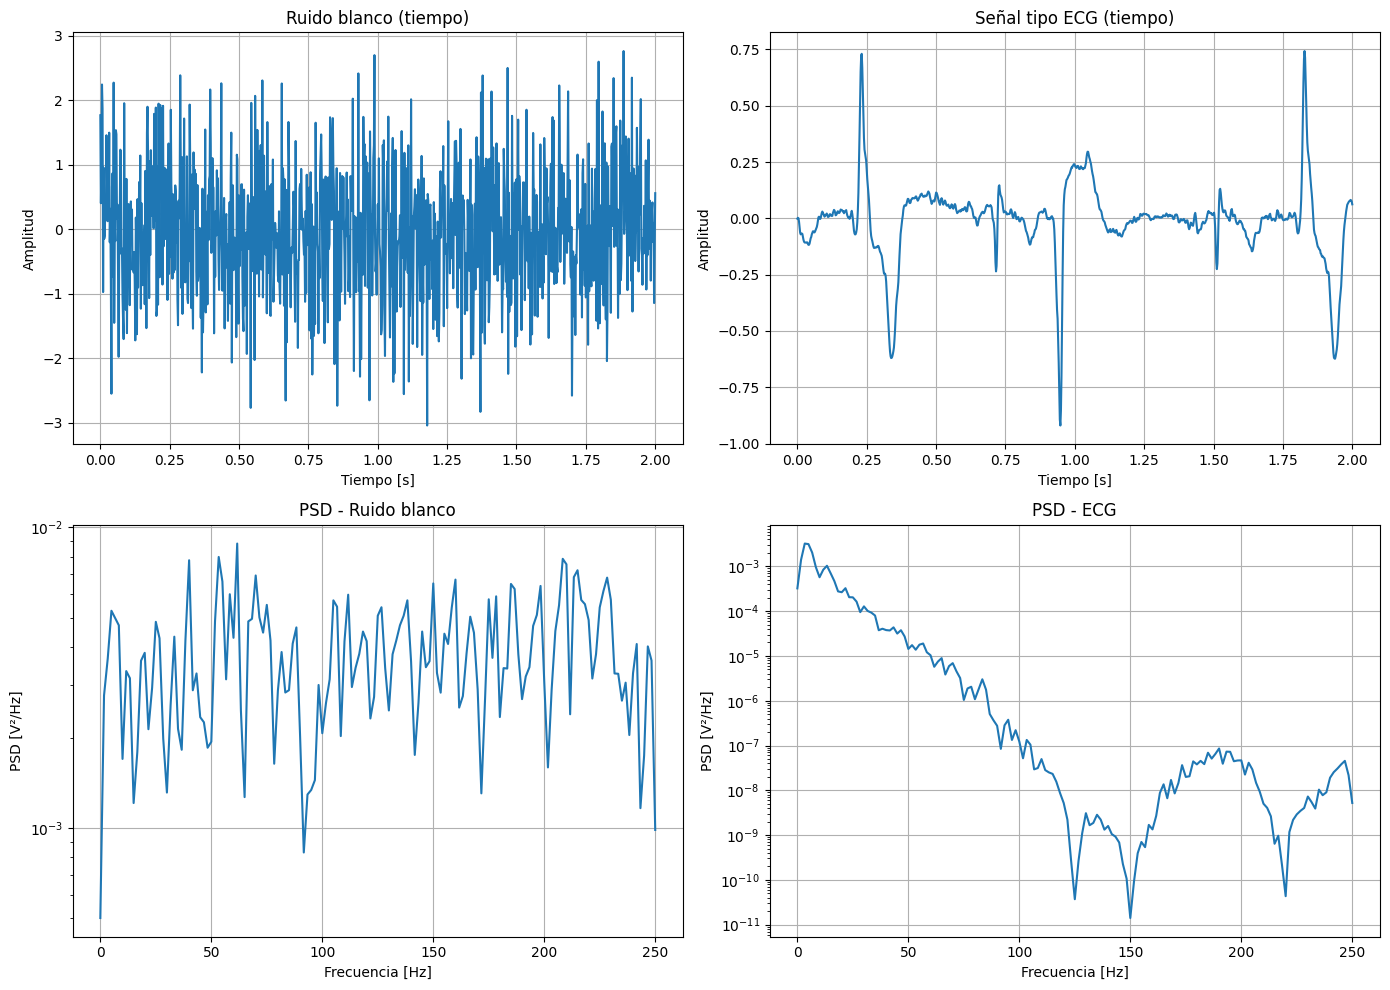

In [10]:
# ----------------------------
# 4) Gráficas
# ----------------------------
plt.figure(figsize=(14, 10))

# ---- Señales en el tiempo ----
plt.subplot(2, 2, 1)
plt.plot(t[:2000], ruido_blanco[:2000])
plt.title("Ruido blanco (tiempo)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(t[:2000], ecg[:2000])
plt.title("Señal tipo ECG (tiempo)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

# ---- PSD ----
plt.subplot(2, 2, 3)
plt.semilogy(f_rw, psd_rw)
plt.title("PSD - Ruido blanco")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.grid(True)

plt.subplot(2, 2, 4)
plt.semilogy(f_ecg, psd_ecg)
plt.title("PSD - ECG")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("PSD [V²/Hz]")
plt.grid(True)

plt.tight_layout()
plt.show()